In [394]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

In [395]:
data = pd.read_csv('bike+sharing+dataset/hour.csv')

data = data.drop(['dteday', 'temp'], axis=1)

X = data.drop('cnt', axis=1).values
y = data['cnt'].values

In [396]:
print(data.head(5))

   instant  season  yr  mnth  hr  holiday  weekday  workingday  weathersit  \
0        1       1   0     1   0        0        6           0           1   
1        2       1   0     1   1        0        6           0           1   
2        3       1   0     1   2        0        6           0           1   
3        4       1   0     1   3        0        6           0           1   
4        5       1   0     1   4        0        6           0           1   

    atemp   hum  windspeed  casual  registered  cnt  
0  0.2879  0.81        0.0       3          13   16  
1  0.2727  0.80        0.0       8          32   40  
2  0.2727  0.80        0.0       5          27   32  
3  0.2879  0.75        0.0       3          10   13  
4  0.2879  0.75        0.0       0           1    1  


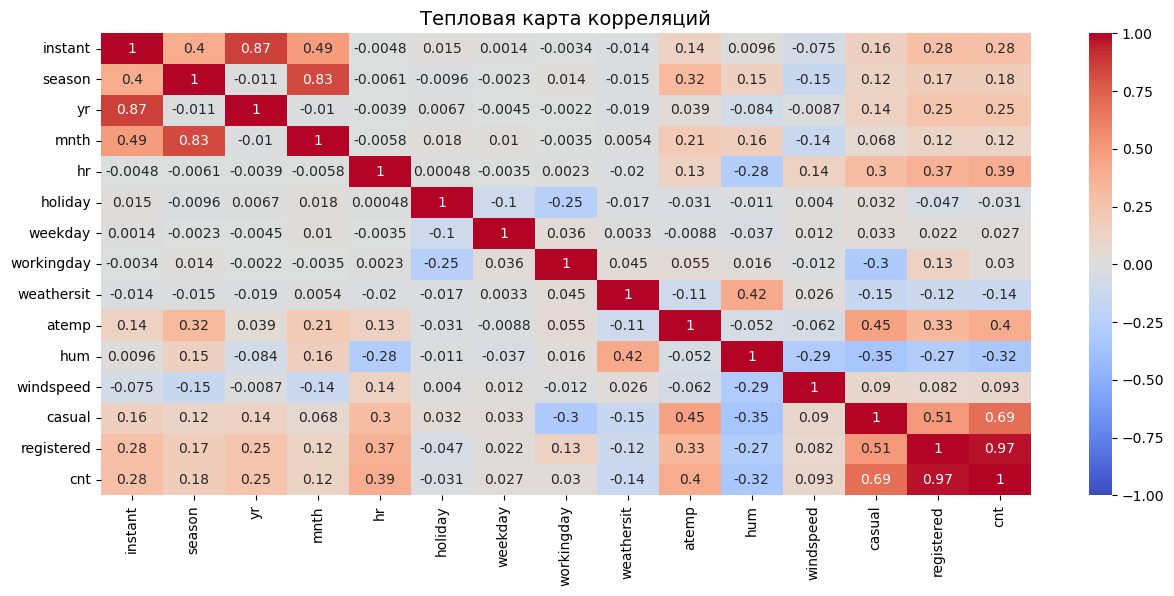

In [397]:
corr_matrix = data.corr()
plt.figure(figsize=(15, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Тепловая карта корреляций', fontsize=14)
plt.show()

In [398]:
split = int(0.8 * len(data))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [399]:
def evaluate_tree(tree, X_train, y_train, X_test, y_test):
    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)
    return {
        'train_r2': r2_score(y_train, train_pred),
        'test_r2': r2_score(y_test, test_pred),
        'depth': tree.get_depth()
    }

results = []

In [400]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20, 25, 30]
for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    scores = evaluate_tree(tree, X_train, y_train, X_test, y_test)
    results.append(('depth', d, scores))
    print(f"depth={d:2d} | train R2={scores['train_r2']:.4f} test R2={scores['test_r2']:.4f} depth={scores['depth']}")

#class sklearn.tree.DecisionTreeRegressor(*, criterion='squared_error', splitter='best', max_depth=None, 
# min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, 
# random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, ccp_alpha=0.0, monotonic_cst=None)

depth= 1 | train R2=0.6535 test R2=0.6035 depth=1
depth= 2 | train R2=0.8650 test R2=0.8495 depth=2
depth= 3 | train R2=0.9413 test R2=0.9256 depth=3
depth= 4 | train R2=0.9695 test R2=0.9620 depth=4
depth= 5 | train R2=0.9849 test R2=0.9816 depth=5
depth= 6 | train R2=0.9928 test R2=0.9887 depth=6
depth= 7 | train R2=0.9964 test R2=0.9944 depth=7
depth= 8 | train R2=0.9983 test R2=0.9964 depth=8
depth= 9 | train R2=0.9992 test R2=0.9973 depth=9
depth=10 | train R2=0.9996 test R2=0.9975 depth=10
depth=11 | train R2=0.9998 test R2=0.9978 depth=11
depth=12 | train R2=0.9999 test R2=0.9979 depth=12
depth=13 | train R2=1.0000 test R2=0.9979 depth=13
depth=14 | train R2=1.0000 test R2=0.9977 depth=14
depth=15 | train R2=1.0000 test R2=0.9978 depth=15
depth=20 | train R2=1.0000 test R2=0.9977 depth=19
depth=25 | train R2=1.0000 test R2=0.9977 depth=19
depth=30 | train R2=1.0000 test R2=0.9977 depth=19


In [401]:
max_depth = 13
leafs = [1, 2, 3, 5, 10, 20, 50]
for leaf in leafs:
    tree = DecisionTreeRegressor(max_depth=max_depth, min_samples_leaf=leaf, random_state=42)
    tree.fit(X_train, y_train)
    scores = evaluate_tree(tree, X_train, y_train, X_test, y_test)
    results.append(('leaf', leaf, scores))
    print(f"leaf={leaf:2d} | train R2={scores['train_r2']:.4f} test R2={scores['test_r2']:.4f}")

leaf= 1 | train R2=1.0000 test R2=0.9979
leaf= 2 | train R2=0.9999 test R2=0.9980
leaf= 3 | train R2=0.9998 test R2=0.9980
leaf= 5 | train R2=0.9996 test R2=0.9976
leaf=10 | train R2=0.9992 test R2=0.9965
leaf=20 | train R2=0.9983 test R2=0.9940
leaf=50 | train R2=0.9954 test R2=0.9899


In [402]:
splits = [2, 3, 4, 5, 6, 7, 8, 9, 10, 50, 100]
for s in splits:
    tree = DecisionTreeRegressor(max_depth=max_depth, min_samples_split=s, min_samples_leaf=1, random_state=42)
    tree.fit(X_train, y_train)
    scores = evaluate_tree(tree, X_train, y_train, X_test, y_test)
    results.append(('split', s, scores))
    print(f"split={s:3d} | train R2={scores['train_r2']:.4f} test R2={scores['test_r2']:.4f}")

split=  2 | train R2=1.0000 test R2=0.9979
split=  3 | train R2=1.0000 test R2=0.9979
split=  4 | train R2=0.9999 test R2=0.9977
split=  5 | train R2=0.9999 test R2=0.9980
split=  6 | train R2=0.9999 test R2=0.9980
split=  7 | train R2=0.9998 test R2=0.9977
split=  8 | train R2=0.9998 test R2=0.9978
split=  9 | train R2=0.9998 test R2=0.9978
split= 10 | train R2=0.9997 test R2=0.9976
split= 50 | train R2=0.9981 test R2=0.9945
split=100 | train R2=0.9958 test R2=0.9904


In [403]:
criteria = ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
for c in criteria:
    tree = DecisionTreeRegressor(max_depth=max_depth, criterion=c, min_samples_split=5, min_samples_leaf=1, random_state=42)
    tree.fit(X_train, y_train)
    scores = evaluate_tree(tree, X_train, y_train, X_test, y_test)
    results.append(('criterion', c, scores))
    print(f"criterion={c:15s} | train R2={scores['train_r2']:.4f} test R2={scores['test_r2']:.4f}")

criterion=squared_error   | train R2=0.9999 test R2=0.9980
criterion=friedman_mse    | train R2=0.9999 test R2=0.9980
criterion=absolute_error  | train R2=0.9999 test R2=0.9976
criterion=poisson         | train R2=0.9999 test R2=0.9977


In [404]:
features = [2, 4, 8, 10, 11, 12, 15, 20]
for f in features:
    tree = DecisionTreeRegressor(max_depth=max_depth, max_features=f, criterion='squared_error',
                                 min_samples_split=5, min_samples_leaf=1, random_state=42)
    tree.fit(X_train, y_train)
    scores = evaluate_tree(tree, X_train, y_train, X_test, y_test)
    results.append(('max_features', f, scores))
    print(f"max_features={f:4} | train R2={scores['train_r2']:.4f} test R2={scores['test_r2']:.4f}")

max_features=   2 | train R2=0.9892 test R2=0.9054
max_features=   4 | train R2=0.9912 test R2=0.9509
max_features=   8 | train R2=0.9996 test R2=0.9926
max_features=  10 | train R2=0.9999 test R2=0.9970
max_features=  11 | train R2=0.9999 test R2=0.9969
max_features=  12 | train R2=0.9999 test R2=0.9980
max_features=  15 | train R2=0.9999 test R2=0.9980
max_features=  20 | train R2=0.9999 test R2=0.9980


In [405]:
alphas = [0.0, 0.0005, 0.001, 0.005, 0.01]
for a in alphas:
    tree = DecisionTreeRegressor(ccp_alpha=a, max_depth=max_depth, max_features=12,
                                 criterion='squared_error', min_samples_split=5, min_samples_leaf=1, random_state=42)
    tree.fit(X_train, y_train)
    scores = evaluate_tree(tree, X_train, y_train, X_test, y_test)
    results.append(('ccp_alpha', a, scores))
    print(f"ccp_alpha={a:.4f} | train R2={scores['train_r2']:.4f} test R2={scores['test_r2']:.4f} depth={scores['depth']}")

ccp_alpha=0.0000 | train R2=0.9999 test R2=0.9980 depth=13
ccp_alpha=0.0005 | train R2=0.9999 test R2=0.9980 depth=13
ccp_alpha=0.0010 | train R2=0.9999 test R2=0.9980 depth=13
ccp_alpha=0.0050 | train R2=0.9998 test R2=0.9980 depth=13
ccp_alpha=0.0100 | train R2=0.9997 test R2=0.9979 depth=13


In [406]:
best = max(results, key=lambda x: x[2]['test_r2'])
print(f"\nЛучшая модель: параметр={best[0]}, значение={best[1]}, test R2={best[2]['test_r2']:.4f}")


Лучшая модель: параметр=split, значение=5, test R2=0.9980


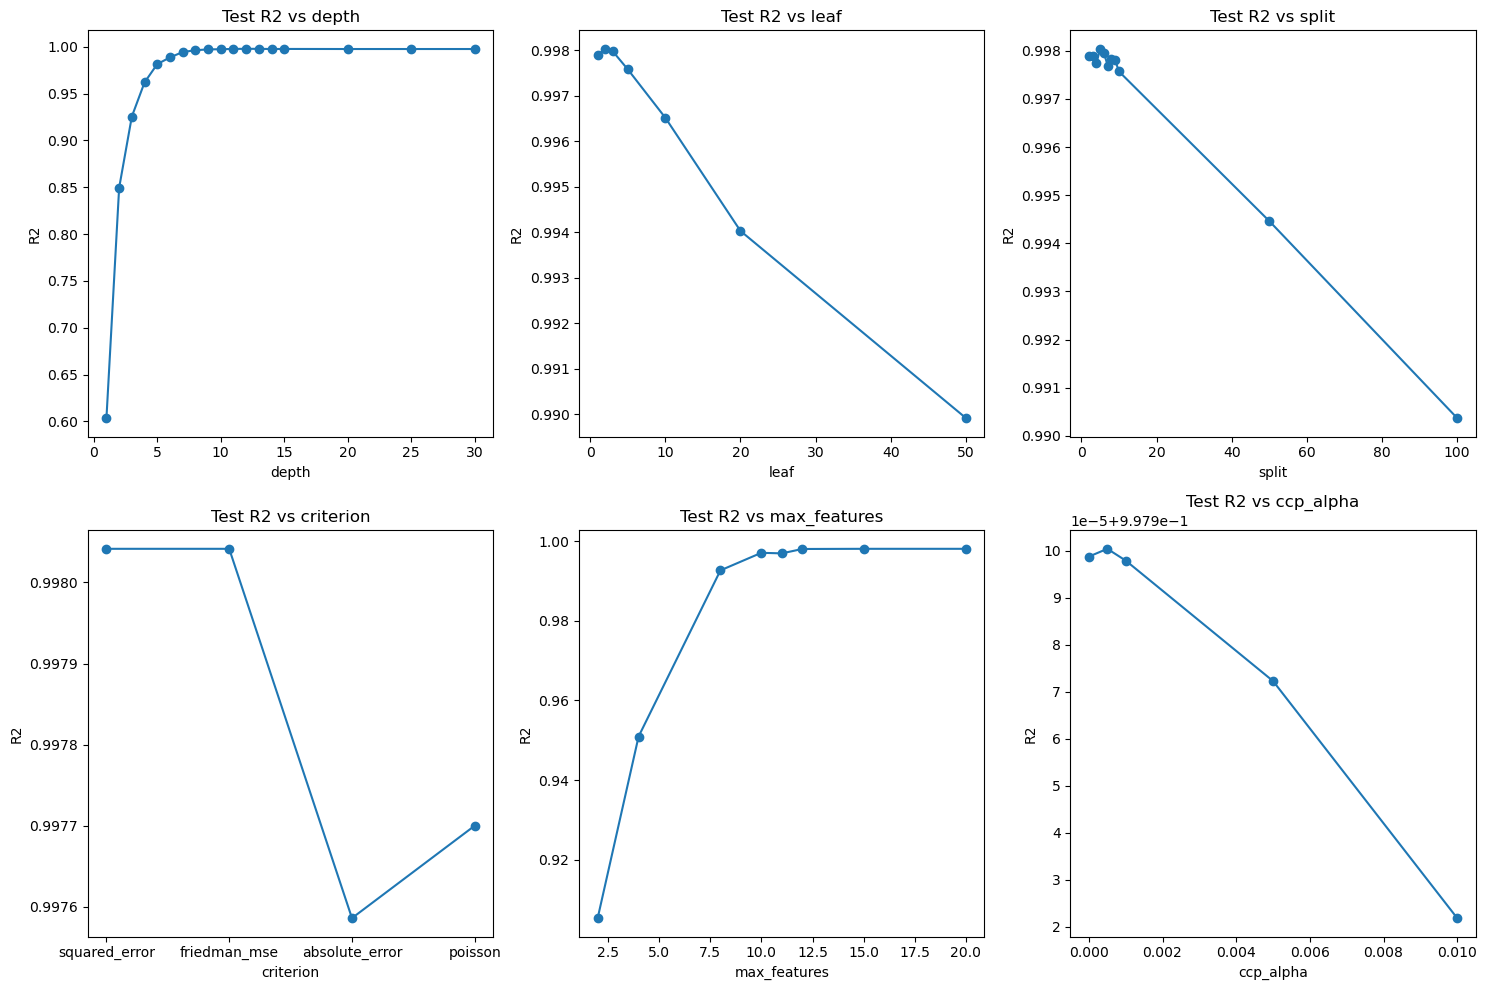

In [407]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
param_names = ['depth', 'leaf', 'split', 'criterion', 'max_features', 'ccp_alpha']
for ax, pname in zip(axes.flatten(), param_names):
    sub = [r for r in results if r[0] == pname]
    if not sub:
        continue
    x = [s[1] for s in sub]
    y = [s[2]['test_r2'] for s in sub]
    ax.plot(x, y, marker='o')
    ax.set_title(f'Test R2 vs {pname}')
    ax.set_xlabel(pname)
    ax.set_ylabel('R2')
plt.tight_layout()
plt.show()

In [408]:
final_tree = DecisionTreeRegressor(
    max_depth=20, max_features=15, criterion='poisson',
    min_samples_split=4, min_samples_leaf=1, ccp_alpha=0.0005,
    random_state=42
)
final_tree.fit(X_train, y_train)
y_pred = final_tree.predict(X_test)
print(f"\nФинальная модель:")
print(f"Train R2: {r2_score(y_train, final_tree.predict(X_train)):.4f}")
print(f"Test R2:  {r2_score(y_test, y_pred):.4f}")
print(f"Глубина:  {final_tree.get_depth()}")


Финальная модель:
Train R2: 0.9983
Test R2:  0.9955
Глубина:  10
